# Log-Normal Distribution Fitting via SPY Option Chains

Fits a **2-parameter log-normal law** for the terminal SPY price $S_T$ using call and put mid-prices at three separate DTE horizons:

- **14 DTE** — ~2-week expiry
- **30 DTE** — ~1-month expiry  
- **45 DTE** — ~1.5-month expiry

Each fit uses only options near that expiry (calls **and** puts) and a CVXPY linearized least-squares step to correct the realized (μ, σ) guess toward market prices.

**Section 4** runs a repeated-sample test over historical windows: for a chosen DTE, we sample many chain dates, fit the log-normal, compute the predicted μ and covariance matrix for (underlying, ATM call, ATM put), then compare to the realized outcomes.

---
## 0. Configuration

In [45]:
# ── Change these ──────────────────────────────────────────────────────────────
ASSET = "SPY"

# Chain date to use for Sections 1–3 (fits + distribution plots).
# Must be far enough in the past that we have realized prices:
#   at least 45 calendar days before last available SPY close.
# Set to None to auto-pick (most recent date with ≥45 days of realized data).
CHAIN_DATE = None   # e.g. "2026-01-12"  or None for auto

# DTE targets for the three fits
DTE_14  = 14
DTE_30  = 30
DTE_45  = 45

# Section 4: repeated-sample test
TEST_DTE       = 30          # which DTE distribution to test (14, 30, or 45)
N_SAMPLES      = 60          # how many historical chain dates to sample
MIN_DAYS_BACK  = 50          # chain date must be at least this many calendar days before last close
LOOKBACK_DAYS  = 21          # trading-day window for realized vol / mu guess
N_SCENARIOS    = 50_000      # Monte Carlo draws for predicted distribution
N_PARAM_DRAWS  = 2_000       # parameter-uncertainty draws
R_ANN          = 0.05        # risk-free rate (annualized)

---
## 1. Setup and data load

In [46]:
%matplotlib inline
import sys, os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cvxpy as cp
from scipy.stats import norm, lognorm
from scipy.optimize import brentq

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from config import OPTION_CHAINS_DIR, SPY_DAILY_FILE, RAW_DIR
from data.forecasts import load_chain_for_expiry, _bs_call_price, _bs_put_price

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.3})
print("Imports OK")

Imports OK


In [47]:
# Load SPY price series
price_file = SPY_DAILY_FILE if ASSET == "SPY" else RAW_DIR / f"{ASSET.lower()}_daily.parquet"
prices = pd.read_parquet(price_file)
prices.index = pd.to_datetime(prices.index).tz_localize(None).normalize()
prices = prices.sort_index()
prices["log_ret"] = np.log(prices["close"] / prices["close"].shift(1))

last_close_date = prices.index.max()
print(f"SPY price range: {prices.index.min().date()} → {last_close_date.date()}")
print(f"Last close: ${prices['close'].iloc[-1]:.2f}")

SPY price range: 2020-01-02 → 2026-02-26
Last close: $689.30


In [48]:
# Discover chain dates and pick the one for fits (must have ≥45 days of realized data)
chain_dir = OPTION_CHAINS_DIR if ASSET == "SPY" else OPTION_CHAINS_DIR / ASSET
all_chain_files = sorted(os.listdir(chain_dir))
chain_dates_all = sorted({
    f.replace("calls_", "").replace("puts_", "").replace(".parquet", "")
    for f in all_chain_files
    if (f.startswith("calls_") or f.startswith("puts_")) and f.endswith(".parquet")
})

MIN_REALIZED_DAYS = 45  # need at least 45 calendar days of realized history
eligible = [
    d for d in chain_dates_all
    if (last_close_date - pd.Timestamp(d)).days >= MIN_REALIZED_DAYS
]

if CHAIN_DATE is not None:
    fit_date = CHAIN_DATE
    assert fit_date in eligible, f"{fit_date} not eligible (need ≥45 days realized data)"
else:
    fit_date = eligible[-1]  # most recent date with ≥45 days of realized data

fit_ts = pd.Timestamp(fit_date)
idx_fit = prices.index.get_indexer([fit_ts], method="ffill")[0]
spot = float(prices.iloc[idx_fit]["close"])

recent_rets = prices.loc[prices.index <= fit_ts, "log_ret"].iloc[-LOOKBACK_DAYS:].dropna()
mu_guess_ann = float(recent_rets.mean() * 252) if len(recent_rets) else 0.0
sigma_guess_ann = .2
#float(recent_rets.std() * np.sqrt(252)) if len(recent_rets) >= 2 else 0.15
sigma_guess_ann = max(sigma_guess_ann, 1e-4)

days_realized = (last_close_date - fit_ts).days
print(f"Fit date (as-of): {fit_date}")
print(f"Spot on fit date: ${spot:.2f}")
print(f"Realized data available: {days_realized} calendar days after fit date")
print(f"Realized guess: mu_ann={mu_guess_ann:+.2%},  sigma_ann={sigma_guess_ann:.2%}")
print(f"Total eligible chain dates: {len(eligible)}")

Fit date (as-of): 2026-01-12
Spot on fit date: $695.16
Realized data available: 45 calendar days after fit date
Realized guess: mu_ann=+13.17%,  sigma_ann=20.00%
Total eligible chain dates: 488


---
## 2. Core helpers: log-normal pricing and fitting

The log-normal model for $S_T$ has two annualized parameters $(\mu_{\text{ann}}, \sigma_{\text{ann}})$:

$$\log S_T \sim \mathcal{N}\!\left(\log S_0 + \left(\mu - \tfrac{1}{2}\sigma^2\right)T,\; \sigma^2 T\right)$$

Options are priced in closed form (Black–Scholes style). We fit $(\mu, \sigma)$ to market mids using one linearized CVXPY least-squares step from the realized guess.

In [49]:
def lognormal_price(K, is_call, mu_ann, sigma_ann, spot_0, T, r=R_ANN):
    """Closed-form log-normal option price (Black-Scholes with arbitrary drift)."""
    sigma_ann = max(float(sigma_ann), 1e-4)
    sigma_t   = max(sigma_ann * np.sqrt(T), 1e-6)
    m  = np.log(spot_0) + (float(mu_ann) - 0.5 * sigma_ann**2) * T
    d2 = (m - np.log(K)) / sigma_t
    d1 = d2 + sigma_t
    mean_st = np.exp(m + 0.5 * sigma_t**2)
    if is_call:
        payoff = mean_st * norm.cdf(d1) - K * norm.cdf(d2)
    else:
        payoff = K * norm.cdf(-d2) - mean_st * norm.cdf(-d1)
    return np.exp(-r * T) * payoff


def lognormal_price_vec(df, mu_ann, sigma_ann, spot_0, T, r=R_ANN):
    """Price a DataFrame of options (columns: strike, type) under log-normal."""
    return np.array([
        lognormal_price(row["strike"], row["type"] == "call",
                        mu_ann, sigma_ann, spot_0, T, r)
        for _, row in df.iterrows()
    ])


def fit_lognormal(option_df, spot_0, T, r=R_ANN,
                  mu_guess=None, sigma_guess=None,
                  recent_log_rets=None):
    """
    Fit (mu_ann, sigma_ann) to option_df market mids via one linearized CVXPY QP step.

    Returns dict with keys: mu_guess, sigma_guess, mu_fit, sigma_fit,
                            param_cov, train_rmse, holdout_rmse, option_df.
    """
    if mu_guess is None:
        mu_guess = float(recent_log_rets.mean() * 252) if recent_log_rets is not None and len(recent_log_rets) else 0.0
    if sigma_guess is None:
        sigma_guess = max(float(recent_log_rets.std() * np.sqrt(252)) if recent_log_rets is not None and len(recent_log_rets) >= 2 else 0.15, 1e-4)

    df = option_df.sort_values(["type", "strike"]).reset_index(drop=True).copy()
    holdout_mask = (np.arange(len(df)) % 5) == 0
    train_df = df.loc[~holdout_mask]

    bump_mu    = max(0.01, 0.25 * max(abs(mu_guess), 0.01))
    bump_sigma = max(0.01, 0.10 * sigma_guess)

    base  = lognormal_price_vec(train_df, mu_guess, sigma_guess, spot_0, T, r)
    jac   = np.column_stack([
        (lognormal_price_vec(train_df, mu_guess + bump_mu, sigma_guess, spot_0, T, r) - base) / bump_mu,
        (lognormal_price_vec(train_df, mu_guess, sigma_guess + bump_sigma, spot_0, T, r) - base) / bump_sigma,
    ])

    step = cp.Variable(2)
    prob = cp.Problem(
        cp.Minimize(cp.sum_squares(base + jac @ step - train_df["market_mid"].to_numpy())),
        [sigma_guess + step[1] >= 0.02]
    )
    prob.solve()
    sv = np.zeros(2) if step.value is None else np.asarray(step.value).reshape(-1)

    mu_fit    = mu_guess    + float(sv[0])
    sigma_fit = max(0.02,  sigma_guess + float(sv[1]))

    df["guess_price"] = lognormal_price_vec(df, mu_guess, sigma_guess, spot_0, T, r)
    df["fit_price"]   = lognormal_price_vec(df, mu_fit,   sigma_fit,   spot_0, T, r)

    def rmse(mask, col):
        return float(np.sqrt(((df.loc[mask, col] - df.loc[mask, "market_mid"]) ** 2).mean()))

    # Local parameter covariance (for sampling uncertainty)
    base_fit  = lognormal_price_vec(train_df, mu_fit, sigma_fit, spot_0, T, r)
    bm_f = max(0.01, 0.25 * max(abs(mu_fit), 0.01))
    bs_f = max(0.01, 0.10 * sigma_fit)
    jac_fit = np.column_stack([
        (lognormal_price_vec(train_df, mu_fit + bm_f, sigma_fit, spot_0, T, r) - base_fit) / bm_f,
        (lognormal_price_vec(train_df, mu_fit, sigma_fit + bs_f, spot_0, T, r) - base_fit) / bs_f,
    ])
    resid = train_df["market_mid"].to_numpy() - base_fit
    dof   = max(len(train_df) - 2, 1)
    mse   = float(np.sum(resid**2) / dof)
    param_cov = mse * np.linalg.pinv(jac_fit.T @ jac_fit)
    param_cov = np.nan_to_num(0.5 * (param_cov + param_cov.T), nan=0.0, posinf=0.0, neginf=0.0)

    return dict(
        mu_guess=mu_guess, sigma_guess=sigma_guess,
        mu_fit=mu_fit,     sigma_fit=sigma_fit,
        param_cov=param_cov,
        train_rmse_guess=rmse(~holdout_mask, "guess_price"),
        train_rmse_fit=rmse(~holdout_mask, "fit_price"),
        holdout_rmse_guess=rmse(holdout_mask, "guess_price"),
        holdout_rmse_fit=rmse(holdout_mask, "fit_price"),
        option_df=df, T=T, r=r, spot=spot_0,
    )


def to_per_share(mid, K, spot_0, is_call, r, T, tol=0.01):
    """Return per-share option mid, or NaN if bounds fail."""
    mid = float(mid)
    if not np.isfinite(mid) or mid <= 0:
        return np.nan
    if is_call:
        lb, ub = 0.0, spot_0
    else:
        lb, ub = max(0.0, K - spot_0), K * np.exp(-r * T)
    if lb - tol <= mid <= ub + tol:
        return mid
    if mid > 5.0 * ub and ub > 0:
        candidate = mid / 100.0
        if lb - tol <= candidate <= ub + tol:
            return candidate
    return np.nan


def load_options_for_dte(chain_date, target_dte, spot_0, r=R_ANN, min_mid=0.02, max_spread=0.80):
    """
    Load calls + puts closest to target_dte, filter to valid per-share mids.
    Returns (option_df, expiry_str, T).
    """
    ref = pd.Timestamp(chain_date)
    meta = pd.read_parquet(chain_dir / f"calls_{chain_date}.parquet")
    meta.columns = [c.replace("impliedVolatility", "impl_vol").lower() for c in meta.columns]
    expiry_arg = None
    if "expiry" in meta.columns:
        expiries  = sorted(meta["expiry"].dropna().unique())
        dte_list  = [(e, (pd.Timestamp(e) - ref).days) for e in expiries
                     if (pd.Timestamp(e) - ref).days > 0]
        if dte_list:
            expiry_arg = min(dte_list, key=lambda x: abs(x[1] - target_dte))[0]

    calls, puts, expiry_used = load_chain_for_expiry(
        chain_date=chain_date, expiry=expiry_arg, underlying=ASSET,
        min_mid=min_mid, max_spread=max_spread,
    )
    if len(calls) == 0 or len(puts) == 0:
        raise ValueError(f"No valid calls/puts on {chain_date} near DTE {target_dte}")

    exp_ts = pd.Timestamp(expiry_used)
    T      = max((exp_ts - ref).days / 365.0, 1e-4)

    rows = []
    for is_call, df_src in [(True, calls), (False, puts)]:
        for _, row in df_src.iterrows():
            K   = float(row["strike"])
            raw = float(row.get("mid", (row.get("bid", 0.0) + row.get("ask", 0.0)) / 2.0))
            mid = to_per_share(raw, K, spot_0, is_call, r, T)
            if np.isfinite(mid):
                rows.append({"strike": K, "type": "call" if is_call else "put", "market_mid": mid})

    if len(rows) < 10:
        raise ValueError(f"Too few valid options after filter on {chain_date} DTE~{target_dte}")

    return pd.DataFrame(rows), expiry_used, T


print("Helpers defined.")

Helpers defined.


---
## 3. Fit log-normal at 14 DTE, 30 DTE, and 45 DTE

For each DTE we:
1. Select the expiry closest to the target DTE from the chain on `fit_date`.
2. Filter calls and puts to valid per-share mid-prices.
3. Fit (μ_ann, σ_ann) via one linearized CVXPY least-squares step.
4. Report train / holdout RMSE and visualize the distribution and pricing error.

In [50]:
# ── Fit all three horizons ──────────────────────────────────────────────────
fits = {}
for label, target_dte in [("14d", DTE_14), ("30d", DTE_30), ("45d", DTE_45)]:
    try:
        opt_df, expiry_str, T_dte = load_options_for_dte(
            fit_date, target_dte, spot, r=R_ANN
        )
        result = fit_lognormal(
            opt_df, spot, T_dte, r=R_ANN,
            mu_guess=mu_guess_ann, sigma_guess=sigma_guess_ann,
        )
        result["expiry"] = expiry_str
        result["actual_dte"] = round(T_dte * 365)
        result["label"] = label
        fits[label] = result
        print(f"[{label}]  expiry={expiry_str}  DTE={result['actual_dte']}  "
              f"n_opts={len(opt_df)}")
        print(f"  Guess:  mu={result['mu_guess']:+.2%}  sigma={result['sigma_guess']:.2%}")
        print(f"  Fitted: mu={result['mu_fit']:+.2%}  sigma={result['sigma_fit']:.2%}")
        print(f"  RMSE  train  guess={result['train_rmse_guess']:.4f}  "
              f"fit={result['train_rmse_fit']:.4f}")
        print(f"  RMSE holdout guess={result['holdout_rmse_guess']:.4f}  "
              f"fit={result['holdout_rmse_fit']:.4f}")
        print()
    except Exception as e:
        print(f"[{label}] FAILED: {e}")

[14d]  expiry=2026-01-26  DTE=14  n_opts=34
  Guess:  mu=+13.17%  sigma=20.00%
  Fitted: mu=+5.63%  sigma=11.80%
  RMSE  train  guess=3.5619  fit=0.6586
  RMSE holdout guess=3.4252  fit=0.5346

[30d]  expiry=2026-02-13  DTE=32  n_opts=146
  Guess:  mu=+13.17%  sigma=20.00%
  Fitted: mu=+4.29%  sigma=13.63%
  RMSE  train  guess=5.5401  fit=1.1160
  RMSE holdout guess=5.7219  fit=1.2748

[45d]  expiry=2026-02-27  DTE=46  n_opts=225
  Guess:  mu=+13.17%  sigma=20.00%
  Fitted: mu=+4.12%  sigma=14.30%
  RMSE  train  guess=6.5266  fit=1.5344
  RMSE holdout guess=6.5584  fit=1.5649



### 3.1 Individual distribution + pricing-error plots

In [ ]:
# # One 2-panel figure per DTE: (left) PDF of S_T, (right) model vs market mid
# COLORS = {"14d": "#2563eb", "30d": "#16a34a", "45d": "#dc2626"}

# for label, res in fits.items():
#     df_plot = res["option_df"]
#     T_  = res["T"]
#     s0  = res["spot"]

#     def _ln_params(mu_a, sig_a):
#         sig_t  = max(sig_a * np.sqrt(T_), 1e-6)
#         m      = np.log(s0) + (mu_a - 0.5 * sig_a**2) * T_
#         return sig_t, np.exp(m)

#     sg, sc = _ln_params(res["mu_guess"], res["sigma_guess"])
#     sf, scf = _ln_params(res["mu_fit"],   res["sigma_fit"])
#     S_grid = np.linspace(s0 * 0.70, s0 * 1.30, 600)

#     fig, axes = plt.subplots(1, 3, figsize=(15, 4))
#     col = COLORS[label]

#     # Left: terminal distribution
#     ax = axes[0]
#     ax.plot(S_grid, lognorm.pdf(S_grid, s=sg, scale=sc),
#             ls="--", lw=1.5, color="gray", label="Guess")
#     ax.plot(S_grid, lognorm.pdf(S_grid, s=sf, scale=scf),
#             lw=2.5, color=col, label="Fit")
#     ax.axvline(s0, color="black", ls=":", alpha=0.6, label=f"Spot={s0:.0f}")
#     ax.set_title(f"[{label}] Terminal $S_T$ distribution  (expiry {res['expiry']})")
#     ax.set_xlabel("$S_T$"); ax.set_ylabel("Density")
#     ax.legend(fontsize=9)

#     # Middle: model vs market (calls)
#     ax = axes[1]
#     for opt_type, marker, ec in [("call", "o", "#16a34a"), ("put", "^", "#dc2626")]:
#         sub = df_plot[df_plot["type"] == opt_type].sort_values("strike")
#         ax.scatter(sub["strike"], sub["market_mid"],
#                    s=14, color="black", marker=marker, zorder=3, alpha=0.7,
#                    label=f"Mkt {opt_type}" if opt_type == "call" else None)
#         ax.scatter(sub["strike"], sub["guess_price"],
#                    s=8, color="gray", marker=marker, alpha=0.4)
#         ax.scatter(sub["strike"], sub["fit_price"],
#                    s=8, color=col, marker=marker, alpha=0.6,
#                    label=f"Fit {opt_type}" if opt_type == "call" else None)
#     ax.axvline(s0, color="black", ls=":", alpha=0.5)
#     ax.set_title(f"[{label}] Model vs market mid ({len(df_plot)} options)")
#     ax.set_xlabel("Strike"); ax.set_ylabel("Option price")
#     ax.legend(fontsize=9)

#     # Right: error vs moneyness
#     ax = axes[2]
#     df_plot = df_plot.copy()
#     df_plot["error"]     = df_plot["fit_price"] - df_plot["market_mid"]
#     df_plot["moneyness"] = df_plot["strike"] / s0
#     for opt_type, ec in [("call", "#16a34a"), ("put", "#dc2626")]:
#         sub = df_plot[df_plot["type"] == opt_type]
#         ax.scatter(sub["moneyness"], sub["error"],
#                    s=20, color=ec, alpha=0.7, label=opt_type)
#     ax.axhline(0, color="black", ls="--", lw=1)
#     ax.set_title(f"[{label}] Pricing error vs moneyness")
#     ax.set_xlabel("Strike / Spot"); ax.set_ylabel("Fit price − Mkt mid ($)")
#     ax.legend(fontsize=9)

#     plt.tight_layout()
#     plt.show()

### 3.2 Overlay: all three fitted distributions

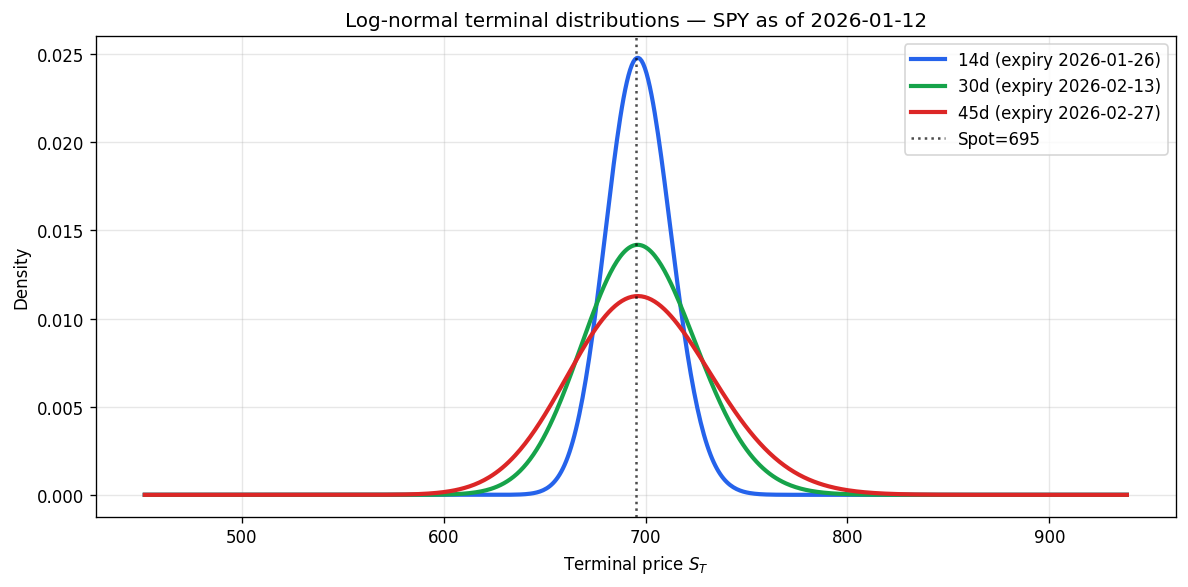

In [52]:
fig, ax = plt.subplots(figsize=(10, 5))

for label, res in fits.items():
    T_  = res["T"]
    s0  = res["spot"]
    sig_t = max(res["sigma_fit"] * np.sqrt(T_), 1e-6)
    m     = np.log(s0) + (res["mu_fit"] - 0.5 * res["sigma_fit"]**2) * T_
    S_grid = np.linspace(s0 * 0.65, s0 * 1.35, 600)
    pdf    = lognorm.pdf(S_grid, s=sig_t, scale=np.exp(m))
    ax.plot(S_grid, pdf, lw=2.5, color=COLORS[label],
            label=f"{label} (expiry {res['expiry']})")

ax.axvline(spot, color="black", ls=":", lw=1.5, alpha=0.7, label=f"Spot={spot:.0f}")
ax.set_xlabel("Terminal price $S_T$")
ax.set_ylabel("Density")
ax.set_title(f"Log-normal terminal distributions — {ASSET} as of {fit_date}")
ax.legend()
plt.tight_layout()
plt.show()

---
## 4. Repeated-sample test: predicted μ and Σ vs realized

We test the chosen log-normal distribution (`TEST_DTE`) over many historical windows:

1. Draw `N_SAMPLES` chain dates from history (at least `MIN_DAYS_BACK` before the last close).  
2. On each date, fit the log-normal to calls + puts at `TEST_DTE`.  
3. Sample parameter uncertainty → sample $S_T$ → compute predicted μ and Σ for  
   **(underlying, ATM call, ATM put)**.  
4. Look up the **realized** outcome at expiry (or at the expiry date using SPY daily data).  
5. Aggregate: distribution of (predicted μ − realized return), predicted Σ vs realized Σ.

In [53]:
# ── Build pool of eligible test dates ──────────────────────────────────────
test_eligible = [
    d for d in chain_dates_all
    if (last_close_date - pd.Timestamp(d)).days >= MIN_DAYS_BACK
]

rng_test = np.random.default_rng(42)
if len(test_eligible) <= N_SAMPLES:
    sampled_dates = test_eligible
else:
    idx_sample = rng_test.choice(len(test_eligible), size=N_SAMPLES, replace=False)
    sampled_dates = [test_eligible[i] for i in sorted(idx_sample)]

print(f"TEST_DTE={TEST_DTE}  eligible={len(test_eligible)}  "
      f"sampling={len(sampled_dates)} dates")

TEST_DTE=30  eligible=485  sampling=60 dates


In [54]:
# ── Run test across sampled dates ──────────────────────────────────────────
ASSET_NAMES = ["underlying", "call", "put"]
test_rows = []   # one row per sampled date: predicted and realized mu
cov_pred_list = []  # predicted 3x3 Σ per date
cov_real_list = []  # realized 3x3 Σ per date

for chain_date in sampled_dates:
    try:
        ref_ts  = pd.Timestamp(chain_date)
        idx_ref = prices.index.get_indexer([ref_ts], method="ffill")[0]
        if idx_ref < 0:
            continue
        spot_ref = float(prices.iloc[idx_ref]["close"])

        opt_df, expiry_str, T_ref = load_options_for_dte(
            chain_date, TEST_DTE, spot_ref, r=R_ANN
        )
        recent_lr = prices.loc[prices.index <= ref_ts, "log_ret"].iloc[-LOOKBACK_DAYS:].dropna()
        mu_g  = float(recent_lr.mean() * 252) if len(recent_lr) else 0.0
        sig_g = max(float(recent_lr.std() * np.sqrt(252)) if len(recent_lr) >= 2 else 0.15, 1e-4)

        res = fit_lognormal(opt_df, spot_ref, T_ref, r=R_ANN,
                            mu_guess=mu_g, sigma_guess=sig_g)

        # ATM call and put (model price and market mid)
        calls_sub = opt_df[opt_df["type"] == "call"]
        puts_sub  = opt_df[opt_df["type"] == "put"]
        if len(calls_sub) == 0 or len(puts_sub) == 0:
            continue
        K_call = float(calls_sub.loc[(calls_sub["strike"] - spot_ref).abs().idxmin(), "strike"])
        K_put  = float(puts_sub.loc[(puts_sub["strike"]  - spot_ref).abs().idxmin(), "strike"])
        C0_model = lognormal_price(K_call, True,  res["mu_fit"], res["sigma_fit"], spot_ref, T_ref)
        P0_model = lognormal_price(K_put,  False, res["mu_fit"], res["sigma_fit"], spot_ref, T_ref)
        C0_mkt   = float(calls_sub[calls_sub["strike"] == K_call]["market_mid"].iloc[0])
        P0_mkt   = float(puts_sub [puts_sub ["strike"] == K_put ]["market_mid"].iloc[0])
        if C0_model < 1e-4 or P0_model < 1e-4 or C0_mkt < 1e-4 or P0_mkt < 1e-4:
            continue

        # ── Predicted distribution via parameter sampling ──
        evals, evecs = np.linalg.eigh(res["param_cov"])
        evals = np.clip(evals, 1e-10, None)
        sqrt_cov = evecs @ np.diag(np.sqrt(evals))
        theta_draws = np.array([res["mu_fit"], res["sigma_fit"]]) + \
            rng_test.standard_normal((N_PARAM_DRAWS, 2)) @ sqrt_cov.T
        mu_draws    = np.clip(theta_draws[:, 0], -2.0, 2.0)
        sigma_draws = np.clip(theta_draws[:, 1], 0.02, 1.0)

        pidx = rng_test.integers(0, N_PARAM_DRAWS, size=N_SCENARIOS)
        z    = rng_test.standard_normal(N_SCENARIOS)
        log_st = (np.log(spot_ref)
                  + (mu_draws[pidx] - 0.5 * sigma_draws[pidx]**2) * T_ref
                  + sigma_draws[pidx] * np.sqrt(T_ref) * z)
        S_T_s = np.exp(log_st)

        R_und_p  = (S_T_s - spot_ref) / spot_ref
        R_call_p = (np.maximum(S_T_s - K_call, 0.0) - C0_model) / C0_model
        R_put_p  = (np.maximum(K_put - S_T_s, 0.0) - P0_model) / P0_model
        R_pred   = np.column_stack([R_und_p, R_call_p, R_put_p])
        mu_pred_v  = R_pred.mean(axis=0)
        Sig_pred   = np.cov(R_pred, rowvar=False)

        # ── Realized outcome ──
        exp_ts  = pd.Timestamp(expiry_str)
        # realized end = expiry or last available, whichever is earlier
        real_end_ts = min(last_close_date, exp_ts)
        idx_end = prices.index.get_indexer([real_end_ts], method="ffill")[0]
        if idx_end < 0:
            continue
        spot_end    = float(prices.iloc[idx_end]["close"])
        R_und_real  = (spot_end - spot_ref) / spot_ref
        R_call_real = (max(spot_end - K_call, 0.0) - C0_mkt) / C0_mkt
        R_put_real  = (max(K_put - spot_end, 0.0)  - P0_mkt) / P0_mkt
        mu_real_v   = np.array([R_und_real, R_call_real, R_put_real])

        # ── Realized DAILY covariance (scaled to period) ──
        try:
            iv_obj = lambda sig: _bs_call_price(spot_ref, K_call, R_ANN, T_ref, sig) - C0_mkt
            iv_atm = float(brentq(iv_obj, 0.01, 2.0))
        except Exception:
            iv_atm = res["sigma_fit"]

        spy_slice  = prices.loc[ref_ts:real_end_ts, "close"]
        dates_sl   = spy_slice.index
        spots_sl   = spy_slice.values.astype(float)
        nd         = len(spots_sl)
        if nd < 3:
            continue

        T_rem = np.array([max((exp_ts - d).days / 365.0, 1e-6) for d in dates_sl])
        cv    = np.zeros(nd)
        pv    = np.zeros(nd)
        for i in range(nd):
            if dates_sl[i] < exp_ts and T_rem[i] > 1 / 365.0:
                cv[i] = max(_bs_call_price(spots_sl[i], K_call, R_ANN, T_rem[i], iv_atm), 0.01)
                pv[i] = max(_bs_put_price( spots_sl[i], K_put,  R_ANN, T_rem[i], iv_atm), 0.01)
            else:
                cv[i] = max(spots_sl[i] - K_call, 0.01)
                pv[i] = max(K_put - spots_sl[i],  0.01)

        r_und_d  = (spots_sl[1:] - spots_sl[:-1]) / spots_sl[:-1]
        r_call_d = (cv[1:] - cv[:-1]) / cv[:-1]
        r_put_d  = (pv[1:] - pv[:-1]) / pv[:-1]
        R_daily  = np.column_stack([r_und_d, r_call_d, r_put_d])
        n_days   = R_daily.shape[0]
        Sig_real = n_days * np.cov(R_daily, rowvar=False)

        test_rows.append(dict(
            chain_date=chain_date,
            expiry=expiry_str,
            actual_dte=round(T_ref * 365),
            spot_entry=spot_ref,
            spot_end=spot_end,
            mu_pred_und=mu_pred_v[0],  mu_real_und=mu_real_v[0],
            mu_pred_call=mu_pred_v[1], mu_real_call=mu_real_v[1],
            mu_pred_put=mu_pred_v[2],  mu_real_put=mu_real_v[2],
            vol_pred_und=float(np.sqrt(max(Sig_pred[0, 0], 0))),
            vol_pred_call=float(np.sqrt(max(Sig_pred[1, 1], 0))),
            vol_pred_put=float(np.sqrt(max(Sig_pred[2, 2], 0))),
            vol_real_und=float(np.sqrt(max(Sig_real[0, 0], 0))),
            vol_real_call=float(np.sqrt(max(Sig_real[1, 1], 0))),
            vol_real_put=float(np.sqrt(max(Sig_real[2, 2], 0))),
        ))
        cov_pred_list.append(Sig_pred)
        cov_real_list.append(Sig_real)

    except Exception:
        continue

test_df = pd.DataFrame(test_rows)
print(f"Test complete: {len(test_df)} windows with valid predictions and realized data.")
if len(test_df) > 0:
    print(test_df[["chain_date", "expiry", "actual_dte",
                   "mu_pred_und", "mu_real_und",
                   "mu_pred_call", "mu_real_call"]].head(10).to_string(index=False))

Test complete: 60 windows with valid predictions and realized data.
chain_date     expiry  actual_dte  mu_pred_und  mu_real_und  mu_pred_call  mu_real_call
2024-03-04 2024-04-05          32     0.004747     0.011966     -0.003844     -0.133423
2024-03-14 2024-04-12          29     0.001932    -0.007962      0.007899     -1.000000
2024-03-18 2024-04-19          32     0.007815    -0.034512      0.001039     -1.000000
2024-03-26 2024-04-26          31     0.008158    -0.020335      0.003469     -1.000000
2024-03-27 2024-04-26          30     0.003363    -0.028499      0.000488     -1.000000
2024-04-01 2024-05-03          32     0.006644    -0.020817      0.003772     -1.000000
2024-04-03 2024-05-03          30     0.006589    -0.015633      0.004680     -1.000000
2024-04-23 2024-05-24          31     0.003019     0.047048      0.006570      1.441667
2024-05-17 2024-06-14          28     0.006182     0.025177      0.006014      0.859649
2024-05-21 2024-06-21          31     0.007857     0

### 4.1 Predicted μ vs realized return — scatter and bias

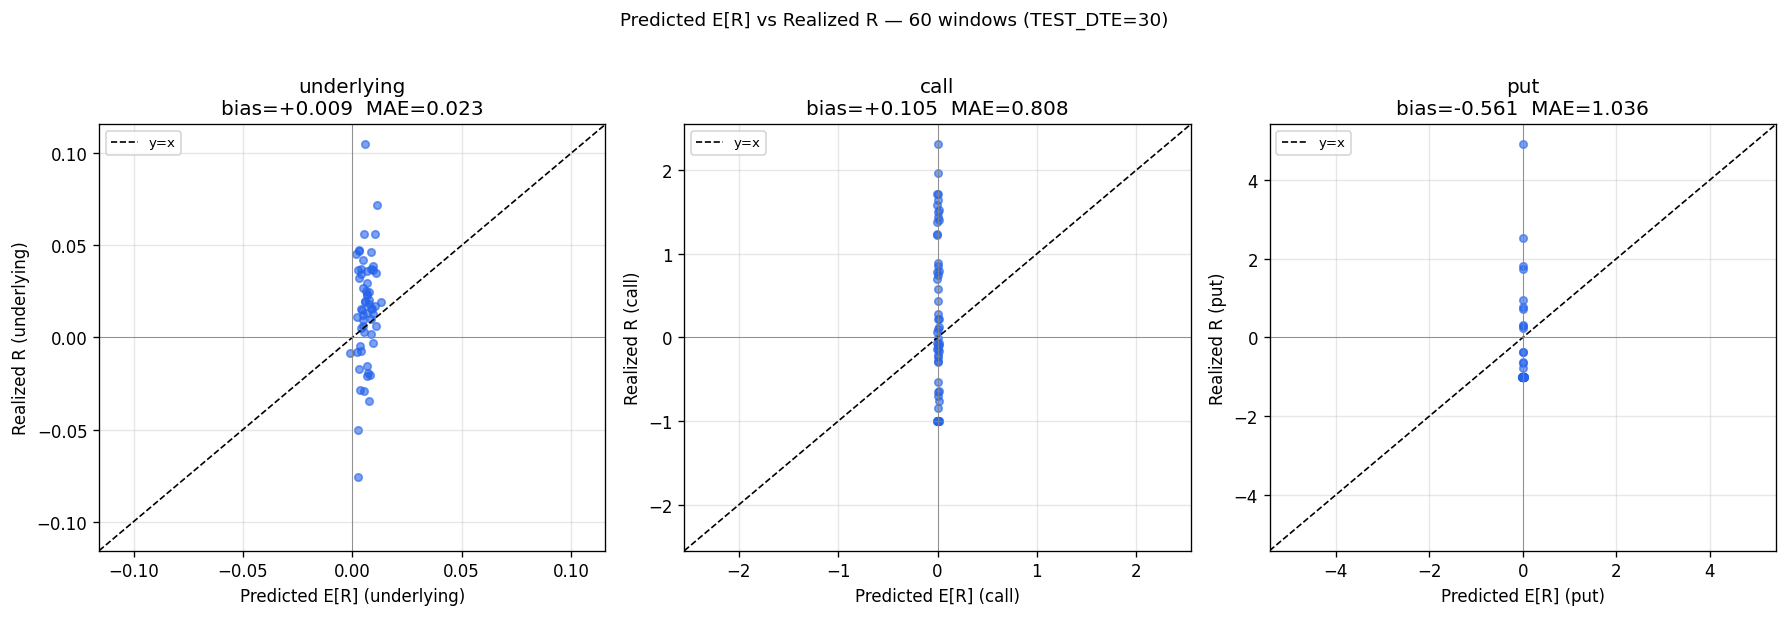

In [55]:
if len(test_df) == 0:
    print("No test results — skipping plots.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, asset, pred_col, real_col in zip(
        axes,
        ASSET_NAMES,
        ["mu_pred_und",  "mu_pred_call",  "mu_pred_put"],
        ["mu_real_und",  "mu_real_call",  "mu_real_put"],
    ):
        x = test_df[pred_col].values
        y = test_df[real_col].values
        ax.scatter(x, y, s=20, alpha=0.6, color="#2563eb")
        lim = max(abs(x).max(), abs(y).max()) * 1.1
        ax.plot([-lim, lim], [-lim, lim], "k--", lw=1, label="y=x")
        ax.axhline(0, color="gray", lw=0.5)
        ax.axvline(0, color="gray", lw=0.5)
        bias = float((y - x).mean())
        mae  = float(np.abs(y - x).mean())
        ax.set_xlabel(f"Predicted E[R] ({asset})")
        ax.set_ylabel(f"Realized R ({asset})")
        ax.set_title(f"{asset}\nbias={bias:+.3f}  MAE={mae:.3f}")
        ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
        ax.legend(fontsize=8)

    plt.suptitle(
        f"Predicted E[R] vs Realized R — {len(test_df)} windows "
        f"(TEST_DTE={TEST_DTE})",
        fontsize=11, y=1.02
    )
    plt.tight_layout()
    plt.show()

### 4.2 Predicted vol vs realized vol per asset

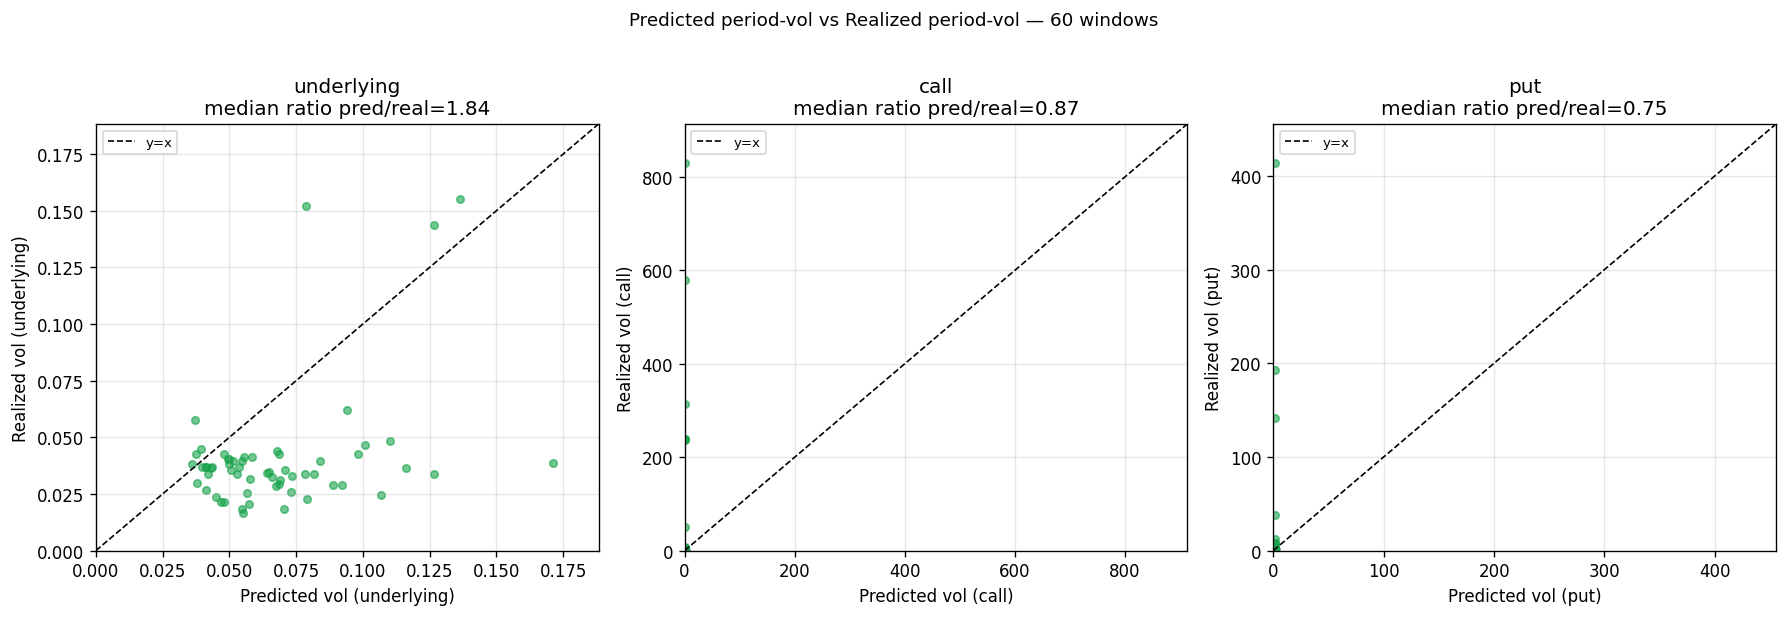

In [56]:
if len(test_df) == 0:
    print("No test results — skipping.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, asset, pred_col, real_col in zip(
        axes,
        ASSET_NAMES,
        ["vol_pred_und",  "vol_pred_call",  "vol_pred_put"],
        ["vol_real_und",  "vol_real_call",  "vol_real_put"],
    ):
        x = test_df[pred_col].values
        y = test_df[real_col].values
        ax.scatter(x, y, s=20, alpha=0.6, color="#16a34a")
        lim = max(x.max(), y.max()) * 1.1
        ax.plot([0, lim], [0, lim], "k--", lw=1, label="y=x")
        ratio = float(np.nanmean(x / np.where(y > 1e-9, y, np.nan)))
        ax.set_xlabel(f"Predicted vol ({asset})")
        ax.set_ylabel(f"Realized vol ({asset})")
        ax.set_title(f"{asset}\nmedian ratio pred/real={np.nanmedian(x/np.where(y>1e-9,y,np.nan)):.2f}")
        ax.set_xlim(0, lim); ax.set_ylim(0, lim)
        ax.legend(fontsize=8)

    plt.suptitle(
        f"Predicted period-vol vs Realized period-vol — {len(test_df)} windows",
        fontsize=11, y=1.02
    )
    plt.tight_layout()
    plt.show()

### 4.3 Average predicted and realized covariance matrices

Average PREDICTED covariance matrix (60 windows, TEST_DTE=30):
            underlying      call       put
underlying    0.005375  0.087194 -0.083475
call          0.087194  2.068435 -1.007919
put          -0.083475 -1.007919  2.288118

Average REALIZED covariance matrix:
            underlying          call          put
underlying    0.002350      1.404954    -0.372150
call          1.404954  21608.937282   -99.932291
put          -0.372150    -99.932291  3845.495926

Average PREDICTED correlation:
            underlying    call     put
underlying      1.0000  0.8269 -0.7527
call            0.8269  1.0000 -0.4633
put            -0.7527 -0.4633  1.0000

Average REALIZED correlation:
            underlying    call     put
underlying      1.0000  0.1972 -0.1238
call            0.1972  1.0000 -0.0110
put            -0.1238 -0.0110  1.0000


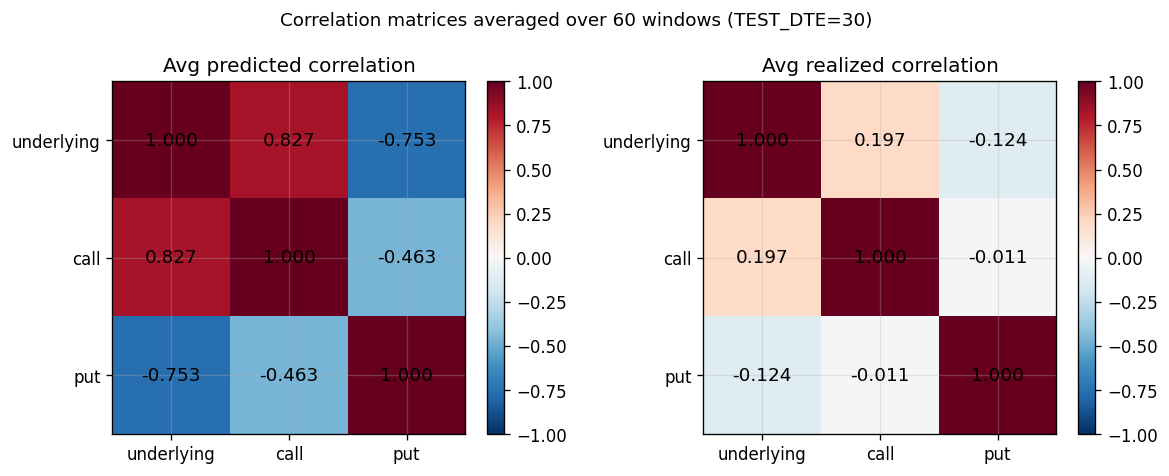

In [57]:
if len(cov_pred_list) == 0:
    print("No covariance data.")
else:
    Sig_pred_avg = np.mean(np.stack(cov_pred_list, axis=0), axis=0)
    Sig_real_avg = np.mean(np.stack(cov_real_list, axis=0), axis=0)

    def _to_corr(S):
        d = np.sqrt(np.maximum(np.diag(S), 1e-20))
        return S / np.outer(d, d)

    print(f"Average PREDICTED covariance matrix ({len(cov_pred_list)} windows, TEST_DTE={TEST_DTE}):")
    print(pd.DataFrame(Sig_pred_avg, index=ASSET_NAMES, columns=ASSET_NAMES).round(6).to_string())

    print(f"\nAverage REALIZED covariance matrix:")
    print(pd.DataFrame(Sig_real_avg, index=ASSET_NAMES, columns=ASSET_NAMES).round(6).to_string())

    print("\nAverage PREDICTED correlation:")
    print(pd.DataFrame(_to_corr(Sig_pred_avg), index=ASSET_NAMES, columns=ASSET_NAMES).round(4).to_string())

    print("\nAverage REALIZED correlation:")
    print(pd.DataFrame(_to_corr(Sig_real_avg), index=ASSET_NAMES, columns=ASSET_NAMES).round(4).to_string())

    # Heatmap comparison
    import matplotlib.colors as mcolors
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, mat, title in [
        (axes[0], _to_corr(Sig_pred_avg), "Avg predicted correlation"),
        (axes[1], _to_corr(Sig_real_avg), "Avg realized correlation"),
    ]:
        im = ax.imshow(mat, vmin=-1, vmax=1, cmap="RdBu_r")
        ax.set_xticks(range(3)); ax.set_yticks(range(3))
        ax.set_xticklabels(ASSET_NAMES); ax.set_yticklabels(ASSET_NAMES)
        for i in range(3):
            for j in range(3):
                ax.text(j, i, f"{mat[i, j]:.3f}", ha="center", va="center",
                        fontsize=11, color="black")
        ax.set_title(title)
        plt.colorbar(im, ax=ax, fraction=0.046)

    plt.suptitle(
        f"Correlation matrices averaged over {len(cov_pred_list)} windows "
        f"(TEST_DTE={TEST_DTE})",
        fontsize=11
    )
    plt.tight_layout()
    plt.show()

### 4.4 Realized-return percentile in predicted distribution

For each window and each asset, we record where the realized return falls in the predicted distribution. Under a well-calibrated model this should be roughly uniform on [0, 100].


── μ prediction summary (mean ± std of error = realized − predicted) ──
  underlying    bias=+0.0091  std=0.0291  MAE=0.0234  corr(pred,real)=0.227
  call          bias=+0.1046  std=0.9753  MAE=0.8080  corr(pred,real)=-0.143
  put           bias=-0.5608  std=1.0664  MAE=1.0356  corr(pred,real)=-0.011

── Volatility ratio (predicted / realized) ──
  underlying    median ratio=1.840  mean ratio=1.947  std=0.918
  call          median ratio=0.874  mean ratio=0.930  std=0.651
  put           median ratio=0.754  mean ratio=0.733  std=0.324


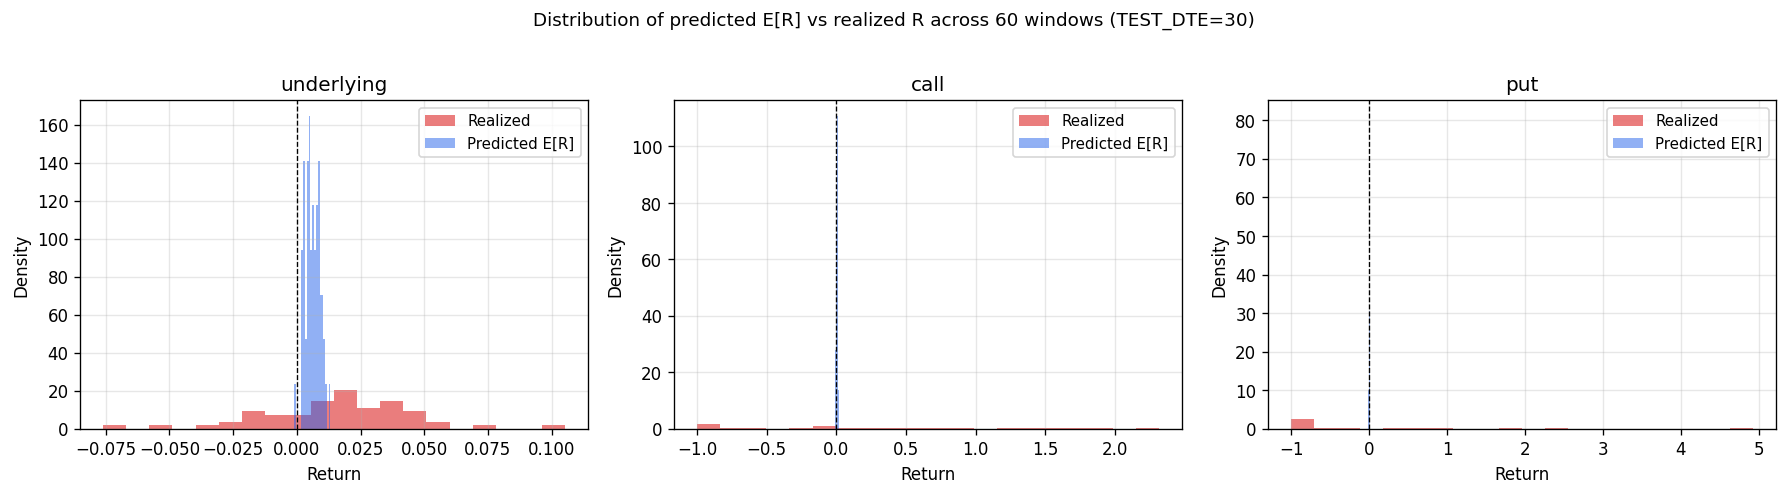

In [58]:
if len(test_df) == 0:
    print("No test results.")
else:
    # Summary statistics
    print("\n── μ prediction summary (mean ± std of error = realized − predicted) ──")
    for asset, pred_col, real_col in zip(
        ASSET_NAMES,
        ["mu_pred_und",  "mu_pred_call",  "mu_pred_put"],
        ["mu_real_und",  "mu_real_call",  "mu_real_put"],
    ):
        err = test_df[real_col] - test_df[pred_col]
        print(f"  {asset:12s}  bias={err.mean():+.4f}  std={err.std():.4f}  "
              f"MAE={err.abs().mean():.4f}  "
              f"corr(pred,real)={test_df[pred_col].corr(test_df[real_col]):.3f}")

    print("\n── Volatility ratio (predicted / realized) ──")
    for asset, pred_col, real_col in zip(
        ASSET_NAMES,
        ["vol_pred_und",  "vol_pred_call",  "vol_pred_put"],
        ["vol_real_und",  "vol_real_call",  "vol_real_put"],
    ):
        ratio = test_df[pred_col] / test_df[real_col].replace(0, np.nan)
        print(f"  {asset:12s}  median ratio={ratio.median():.3f}  "
              f"mean ratio={ratio.mean():.3f}  std={ratio.std():.3f}")

    # Distribution of predicted vs realized returns
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, asset, pred_col, real_col in zip(
        axes, ASSET_NAMES,
        ["mu_pred_und",  "mu_pred_call",  "mu_pred_put"],
        ["mu_real_und",  "mu_real_call",  "mu_real_put"],
    ):
        ax.hist(test_df[real_col], bins=20, alpha=0.6,
                color="#dc2626", label="Realized", density=True)
        ax.hist(test_df[pred_col], bins=20, alpha=0.5,
                color="#2563eb", label="Predicted E[R]", density=True)
        ax.axvline(0, color="black", lw=0.8, ls="--")
        ax.set_title(f"{asset}")
        ax.set_xlabel("Return")
        ax.set_ylabel("Density")
        ax.legend(fontsize=9)

    plt.suptitle(
        f"Distribution of predicted E[R] vs realized R across "
        f"{len(test_df)} windows (TEST_DTE={TEST_DTE})",
        fontsize=11, y=1.02
    )
    plt.tight_layout()
    plt.show()